In [206]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [207]:
npr.random((1,5))

array([[0.97039904, 0.73068657, 0.46212678, 0.0442287 , 0.26946166]])

In [208]:
#Simulation matrices de n*p gaussiennes réelles standards

def normal_standard(n, p) : 

    U = npr.random((n,p))
    V = npr.random((n,p))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

In [209]:
normal_standard(1,5)

array([[ 0.73693323,  1.20561221,  1.36222214, -0.11732044, -0.73523818]])

In [ ]:
# Simulation d'un mouvement brownien standard de dim 1
def mouvement_brownien(T, N):
    """
    Simule une trajectoire d'un mouvement brownien standard.
    Paramètres :
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - t : tableau des temps
    - W : tableau des valeurs du mouvement brownien
    """

    dt = T / N
    t = np.linspace(0, T, N+1)
    W = np.zeros(N+1)

    dW = np.sqrt(dt) * normal_standard(1, N)[0]

    for i in range(1, N+1):
        W[i] = W[i-1] + dW[i-1]

    return t, W

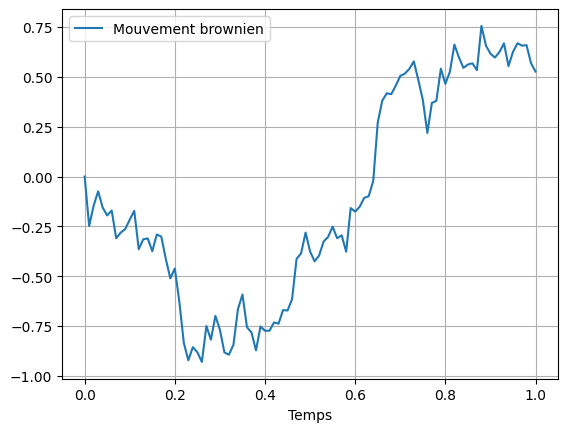

In [211]:
# Test 

t, W = mouvement_brownien(1, 100)

# Affichage
plt.plot(t, W, label='Mouvement brownien')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

In [278]:
# paramètres

T = 1.5   # Temps final
N = 1000  # Nombre de pas de temps

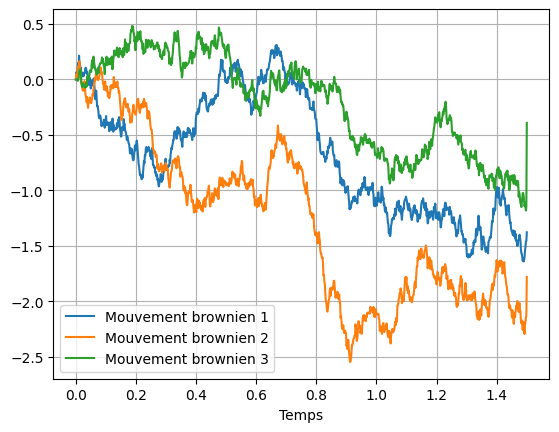

In [279]:
# Simulation des trajectoires Mouvement Bornien Standards Corrélés

def mouvement_brownien_corr(T,N,rho = 0.3) :
    Gamma = np.linalg.cholesky([[1,rho,rho],
                                [rho,1,rho],
                                [rho,rho,1]])
    # 1 : Simulation MB standards de dimension 3
    t1, W1 = mouvement_brownien(T, N)
    _, W2 = mouvement_brownien(T, N)
    _, W3 = mouvement_brownien(T, N)

    # 2 : corrélation des MB : 
    for i in range (0, N):
        [W1[i],W2[i],W3[i]] = Gamma @ [W1[i],W2[i],W3[i]]
    return W1,W2,W3

t = np.linspace(0, T, N+1)
[W1,W2,W3] = mouvement_brownien_corr(T,N)
# Affichage
plt.plot(t, W1, label='Mouvement brownien 1')
plt.plot(t, W2, label='Mouvement brownien 2')
plt.plot(t, W3, label='Mouvement brownien 3')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

Text(0.5, 0, 'W3(T)')

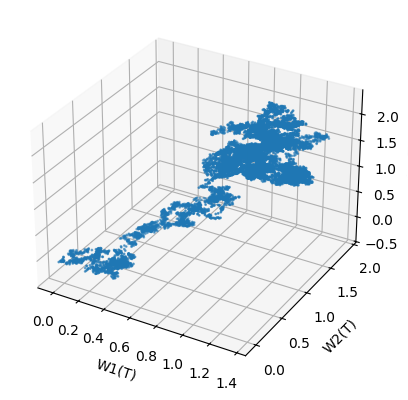

In [ ]:
# Simulation du vecteur gaussien (W1(T), W2(T), W3(T)), centré, de matrice de var-cov Gamma

[W1,W2,W3] = mouvement_brownien_corr(T,10000)
fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(W1,W2,W3,s=1)

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')



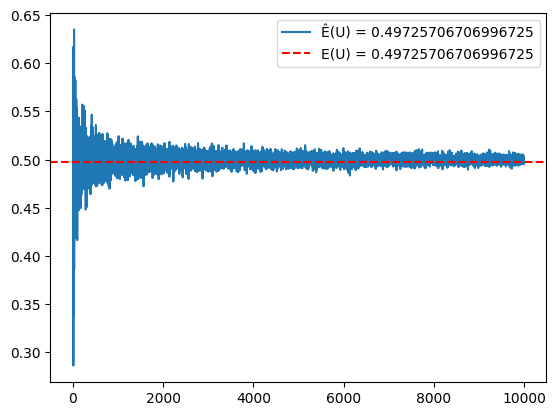

In [372]:
# test approximaton esperance de v.a. uniformes indep
N = 10000
E = np.zeros(N)

for n in range(1,N+1):
    U = np.random.uniform(0, 1, n)
    E[n-1] = (1/n) * np.sum(U)

plt.plot(np.linspace(1,N,N),E, label=f"Ê(U) = {E[-1]}" )
plt.axhline(y=np.mean(U), color='r', linestyle='--', label=f"E(U) = {np.mean(U)}")
plt.legend()
plt.show()

In [428]:
def S(t, N = N, K = 1, r = 0.02, S0 = [1,1,1], sigma = [0.3,0.3,0.3]):
    """
    Simule la solution de l'EDS de Black Scholes
    Paramètres :
    - T : temps 
    - N : nombre de pas de temps
    - K : strike de l'option (constante)
    - r : taux d'intérêt
    - S0 : conditions initiales vecteur de dim 3
    - sigma : vecteur de volatilités

    - W : mouvement brownien standards corrélés

    Retourne :
    - S : Solution de l'EDS
    """
    W1,W2,W3 = mouvement_brownien_corr(t,N)

    S1 = S0[0] * np.exp((r - (1/2)*(sigma[0])**2)*t + sigma[0]*W1)
    S2 = S0[1] * np.exp((r - (1/2)*(sigma[1])**2)*t + sigma[1]*W2)
    S3 = S0[2] * np.exp((r - (1/2)*(sigma[2])**2)*t + sigma[2]*W3)

    return S1,S2,S3

In [ ]:
np.stack(S(1.5,1)) # ici on a [Si(0), Si(T)]i (il y a un seul pas de temps)

array([[0.96319442, 1.07107797],
       [0.96319442, 0.58818019],
       [0.96319442, 0.91189768]])

In [ ]:
def P1(N, T, K = 1, r = 0.02):

    # approximation de l'esperance du maxmimum
    maxi = np.zeros(N)

    for n in range(1,N+1):
        s1,s2,s3 = S(1.5, n)
        
        maxi[n-1] = np.max([s1[-1],s2[-1],s2[-1]])

    E = (1/N) * np.sum(maxi)

    return np.exp(-r * T) * (E - K)

In [490]:
def P1(N, T, K = 1, r = 0.02):
    maxSi = np.zeros(N)
    for n in range(N) : 
        ST = np.stack(S(T,1))[:,1] # np.stack permet de convertir list of array en un array of (list of list) (i.e une matrice)
        maxSi[n] = np.max(ST)

    E = (1/N)*np.sum(maxSi)
    #print(E)

    return np.exp(-r * T) * (E - K)

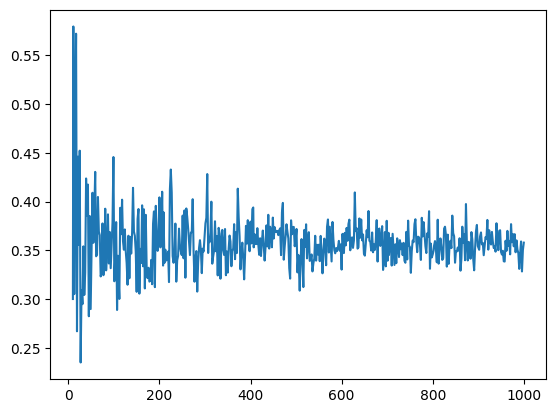

In [491]:
# test
m = 501
n = np.linspace(10,1000,m).astype(int)

P = np.zeros(m)
for i in range(m) :
    P[i] = P1(n[i],1.5)

#print(P)

plt.plot(n,P)